In [1]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RandomForestRegressor': RandomForestRegressor()
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name} - Mean Squared Error: {mse:.2f}')

LinearRegression - Mean Squared Error: 2900.19
Ridge - Mean Squared Error: 3077.42
RandomForestRegressor - Mean Squared Error: 2995.35


Linear Regression: MAE = 52.26
Ridge: MAE = 55.96
Lasso: MAE = 54.28


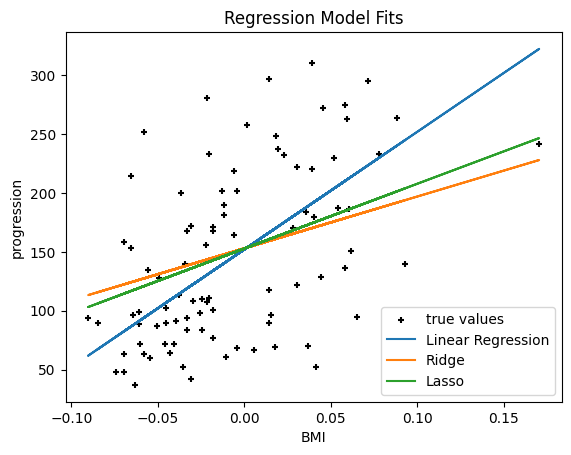

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

x = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
}

plt.scatter(x_test, y_test, color='black', s=20, marker='+', label='true values')

for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    plt.plot(x_test, predictions, label=name)
    mae = mean_absolute_error(y_test, predictions)
    print(f'{name}: MAE = {mae:.2f}')
plt.xlabel('BMI')
plt.ylabel('progression')
plt.title('Regression Model Fits')
plt.legend()
plt.show()

Linear Regression RMSE: 62.33
Decision Tree RMSE: 68.98
Random Forest RMSE: 66.05


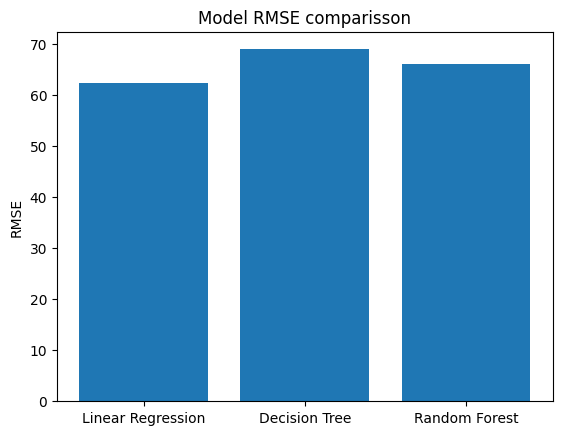

[('Linear Regression', np.float64(62.32926055201547)),
 ('Decision Tree', np.float64(68.9764702806758)),
 ('Random Forest', np.float64(66.05338909461413))]

In [6]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
]

rmse_scores = []

for name, model in models:
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append((name, rmse))
    print(f'{name} RMSE: {rmse:.2f}')

names, scores = zip(*rmse_scores)
plt.bar(names, scores)
plt.ylabel('RMSE')
plt.title('Model RMSE comparisson')
plt.show()
rmse_scores

Linear Regression R2: 0.28
Decision Tree R2: 0.12
Random Forest R2: 0.19


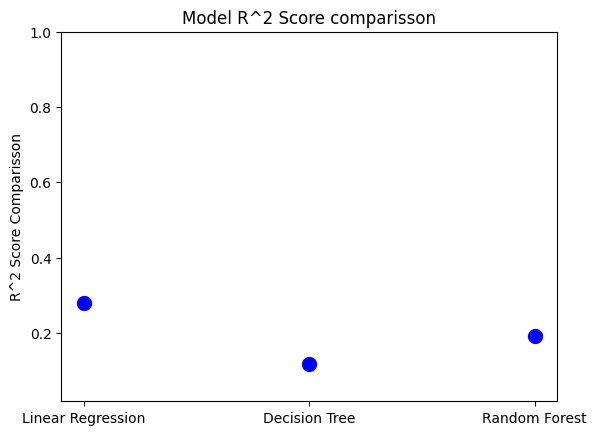

[('Linear Regression', 0.2803417492440603),
 ('Decision Tree', 0.11865835327646945),
 ('Random Forest', 0.19177445908340685)]

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
]

r2_scores = []

for name, model in models:
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    r2 = model.score(x_test, y_test)
    r2_scores.append((name, r2))
    print(f'{name} R2: {r2:.2f}')

names, scores = zip(*r2_scores)
plt.scatter(names, scores, color='blue', s=100)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('R^2 Score Comparisson')
plt.title('Model R^2 Score comparisson')
plt.ylim(min(scores) -0.1,1)
plt.show()
r2_scores

Linear Regression MAPE: 37.50
Decision Tree MAPE: 45.44
Random Forest MAPE: 40.01


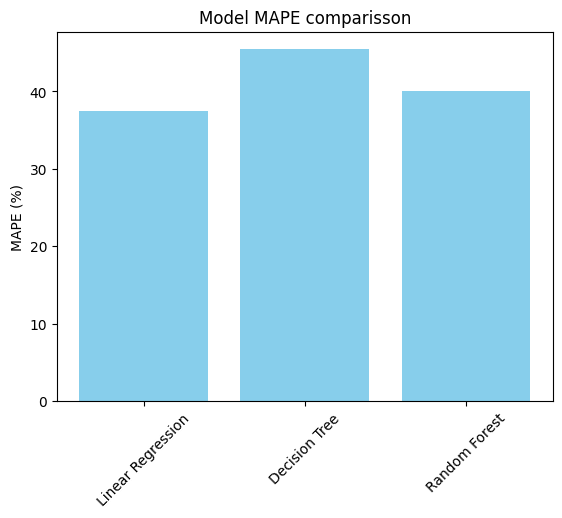

[('Linear Regression', np.float64(37.49982636756113)),
 ('Decision Tree', np.float64(45.43656929988135)),
 ('Random Forest', np.float64(40.00528510559908))]

In [14]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
x, y = diabetes.data, diabetes.target

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

def mean_absolute_percentage_error(y_true, y_pred):
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  non_zero_indices = y_true != 0
  return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

  models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

mape_scores = []

for name, model in models:
  model.fit(x_train, y_train)
  predictions = model.predict(x_test)
  mape = mean_absolute_percentage_error(y_test, predictions)
  mape_scores.append((name, mape))
  print(f'{name} MAPE: {mape:.2f}')

names, scores = zip(*mape_scores)
plt.bar(names, scores, color = 'skyblue')
plt.ylabel('MAPE (%)')
plt.title('Model MAPE comparisson')
plt.xticks(rotation=45)
plt.show()
mape_scores

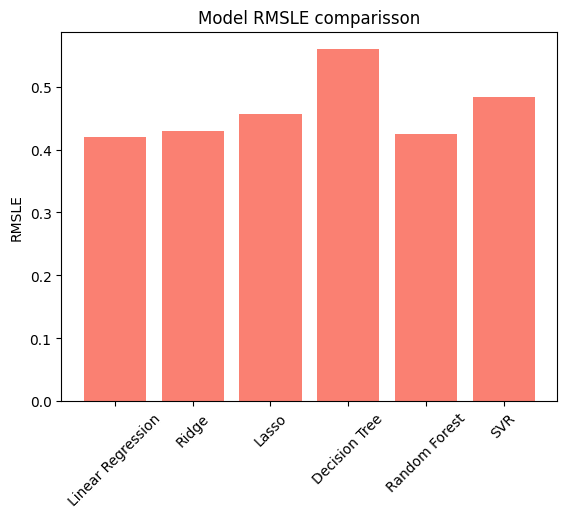

In [18]:
from sklearn.metrics import mean_squared_log_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()
x, y = diabetes.data, diabetes.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

def root_mean_squared_error(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, np.inf)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

rmsle_scores = []

for name, model in models:
  model.fit(x_train, y_train)
  predictions = model.predict(x_test)
  rmsle = root_mean_squared_error(y_test, predictions)
  rmsle_scores.append((name, rmsle))

names, scores = zip(*rmsle_scores)
plt.bar(names, scores, color='salmon')
plt.ylabel('RMSLE')
plt.title('Model RMSLE comparisson')
plt.xticks(rotation=45)
plt.show()